In [1]:
import os, math, random, gc, shutil
import numpy as np
import pandas as pd
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (cohen_kappa_score, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report)

In [2]:
KAGGLE_INPUT = '/kaggle/input/datasets/almiraraisa/aptos-2019-224px-aug-v2'
DATASET_DIR  = '/kaggle/input/datasets/almiraraisa/aptos-2019-224px-aug-v2'
if not os.path.exists(DATASET_DIR):
    zip_files = list(Path(KAGGLE_INPUT).glob('*.zip'))
    if zip_files: shutil.unpack_archive(zip_files[0], DATASET_DIR)
    else: shutil.copytree(KAGGLE_INPUT, DATASET_DIR)

device       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASS_NAMES  = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative DR']
NUM_CLASSES  = len(CLASS_NAMES)
BATCH_SIZE   = 32
NUM_EPOCHS   = 100
LR           = 1e-4
WEIGHT_DECAY = 1e-5
CKPT_DIR     = '/kaggle/working'
os.makedirs(CKPT_DIR, exist_ok=True)
print(f"Device: {device}")

Device: cpu


In [3]:
def set_seed(seed=35):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False

def cleanup_memory():
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

In [4]:
class AptosDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_col = 'id_code' if 'id_code' in self.df.columns else self.df.columns[0]
        fname = str(row[img_col]); fname = fname if fname.endswith('.png') else fname + '.png'
        img = Image.open(self.image_dir / fname).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, torch.tensor(int(row['diagnosis']), dtype=torch.long)

In [5]:
plain_tfm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_df = pd.read_csv(f'{DATASET_DIR}/train_split.csv')
val_df   = pd.read_csv(f'{DATASET_DIR}/val_split.csv')
test_df  = pd.read_csv(f'{DATASET_DIR}/test_split.csv')

train_df['diagnosis'] = train_df['diagnosis'].astype(int)
class_counts   = train_df['diagnosis'].value_counts().sort_index().values
sample_weights = train_df['diagnosis'].map(lambda x: 1.0 / class_counts[x]).values

class_counts   = train_df['diagnosis'].value_counts().sort_index().values
sample_weights = train_df['diagnosis'].map(lambda x: 1.0 / class_counts[x]).values
sampler = WeightedRandomSampler(torch.tensor(sample_weights, dtype=torch.float),
                                len(sample_weights), replacement=True)
train_loader = DataLoader(AptosDataset(train_df, f'{DATASET_DIR}/images', plain_tfm),
                          batch_size=BATCH_SIZE, sampler=sampler, num_workers=4, pin_memory=True)
val_loader   = DataLoader(AptosDataset(val_df,   f'{DATASET_DIR}/images', plain_tfm),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(AptosDataset(test_df,  f'{DATASET_DIR}/images', plain_tfm),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

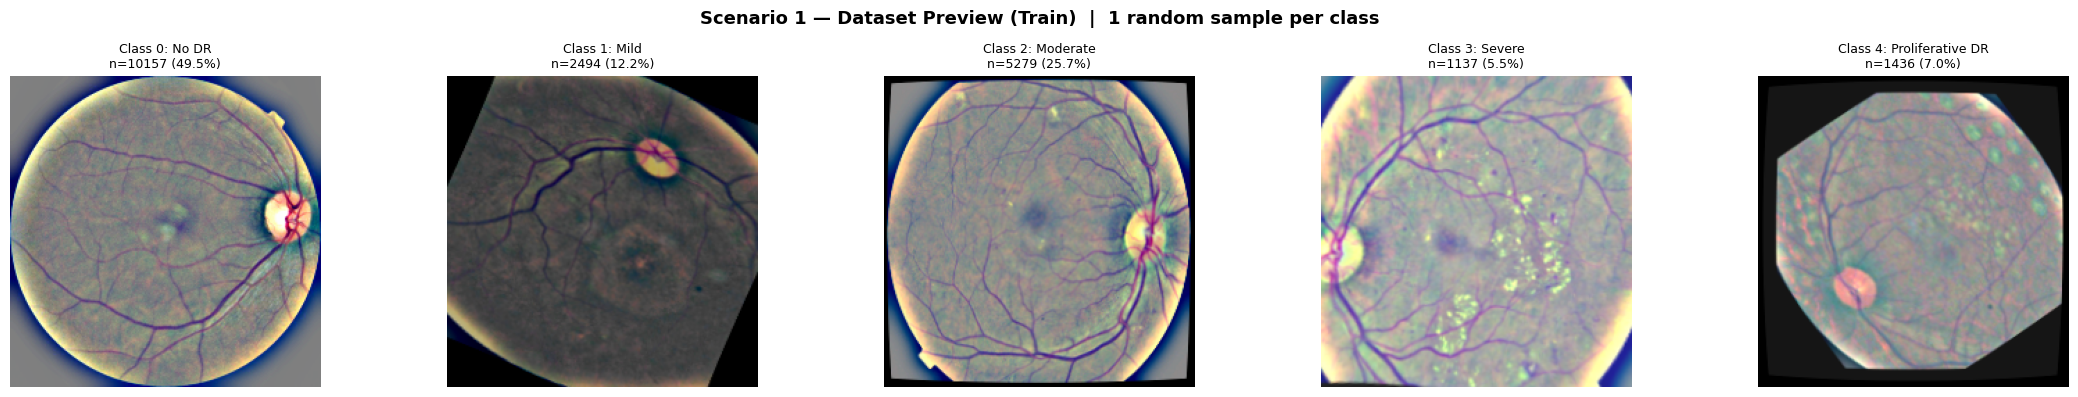


── Dataset Statistics ──────────────────────────────────
  Train: 20503 | Val: 366 | Test: 367
  Class distribution (train):
  [0] No DR               : 10157 ( 49.5%)  ██████████████
  [1] Mild                : 2494 ( 12.2%)  ███
  [2] Moderate            : 5279 ( 25.7%)  ███████
  [3] Severe              : 1137 (  5.5%)  █
  [4] Proliferative DR    : 1436 (  7.0%)  ██


In [6]:
def preview_dataset(df, image_dir, split_name="Train"):
    image_dir = Path(image_dir)
    img_col   = 'id_code' if 'id_code' in df.columns else df.columns[0]
    fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(22, 4))
    fig.suptitle(f"Scenario 1 — Dataset Preview ({split_name})  |  1 random sample per class",
                 fontsize=13, fontweight='bold')
    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        subset = df[df['diagnosis'] == cls_idx]
        row    = subset.sample(1, random_state=42).iloc[0]
        fname  = str(row[img_col]); fname = fname if fname.endswith('.png') else fname + '.png'
        img    = Image.open(image_dir / fname).convert('RGB')
        axes[cls_idx].imshow(img)
        axes[cls_idx].set_title(
            f"Class {cls_idx}: {cls_name}\nn={len(subset)} ({100*len(subset)/len(df):.1f}%)",
            fontsize=9)
        axes[cls_idx].axis('off')
    plt.tight_layout()
    plt.savefig(f'{CKPT_DIR}/dataset_preview.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("\n── Dataset Statistics ──────────────────────────────────")
    print(f"  Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
    print("  Class distribution (train):")
    for i, name in enumerate(CLASS_NAMES):
        n = (train_df['diagnosis'] == i).sum()
        bar = '█' * int(30 * n / len(train_df))
        print(f"  [{i}] {name:<20s}: {n:4d} ({100*n/len(train_df):5.1f}%)  {bar}")

preview_dataset(train_df, f'{DATASET_DIR}/images')

In [7]:
class CornHead(nn.Module):
    def __init__(self, in_features, num_classes):
        super().__init__()
        self.classifiers = nn.ModuleList(
            [nn.Linear(in_features, 1) for _ in range(num_classes - 1)]
        )

    def forward(self, x):
        return [clf(x) for clf in self.classifiers]

def corn_forward(model, imgs):
    feat = model.classifier(model.features(imgs).mean([2, 3]))
    return model.corn_head(feat)   # list of K-1 tensors, each (B,1)


def corn_loss(logit_list, labels, num_classes=NUM_CLASSES):
    """
    For each rank k (0-indexed boundary between k and k+1):
      - Only use samples where label >= k  (the 'conditional' subset)
      - Target = 1 if label >= k+1, else 0
    """
    total_loss = torch.tensor(0.0, device=labels.device)
    for k, logits in enumerate(logit_list):
        # Conditional subset: samples with label >= k
        mask = labels >= k
        if mask.sum() == 0:
            continue
        subset_logits  = logits[mask].squeeze(1)          # (M,)
        subset_targets = (labels[mask] > k).float()       # 1 if label >= k+1
        total_loss     = total_loss + F.binary_cross_entropy_with_logits(
                             subset_logits, subset_targets)
    return total_loss / (num_classes - 1)


def corn_predict(logit_list):
    """
    Reconstruct P(Y >= k) = prod_{j=0}^{k-1} sigmoid(logit_j)
    Then predicted class = sum_k [P(Y >= k) > 0.5]
    """
    # Stack conditional probs: (B, K-1)
    cond_probs = torch.cat([torch.sigmoid(l) for l in logit_list], dim=1)
    # Cumulative product for joint probabilities
    cum_probs  = torch.cumprod(cond_probs, dim=1)          # (B, K-1)
    return (cum_probs > 0.5).sum(dim=1).long()

In [8]:
def get_mobilenet_v3_small_corn():
    m = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
    in_features = m.classifier[-1].in_features
    m.classifier[-1] = nn.Identity()
    m.corn_head = CornHead(in_features, NUM_CLASSES)
    return m

In [9]:
def evaluate_on_test_corn(model, loader):
    model.eval(); t_preds, t_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            logit_list = corn_forward(model, imgs.to(device))
            preds      = corn_predict(logit_list)
            t_preds.extend(preds.cpu().numpy())
            t_labels.extend(labels.numpy())
    t_preds  = np.array(t_preds); t_labels = np.array(t_labels)
    qwk  = float(cohen_kappa_score(t_labels, t_preds, weights='quadratic'))
    acc  = float(np.mean(t_labels == t_preds))
    mse  = float(np.mean((t_labels - t_preds) ** 2))
    return {'qwk': qwk, 'acc': acc, 'mse': mse,
            'rmse': float(np.sqrt(mse)), 'mae': float(np.mean(np.abs(t_labels - t_preds))),
            'preds': t_preds.tolist(), 'labels': t_labels.tolist()}

In [10]:
def train_corn(model, seed):
    save_path      = f'{CKPT_DIR}/corn_seed{seed}_best.pth'
    last_save_path = f'{CKPT_DIR}/corn_seed{seed}_last.pth'
    model = model.to(device)

    opt = optim.AdamW([
        {'params': [p for n, p in model.named_parameters() if 'corn_head' not in n]},
        {'params': model.corn_head.parameters(), 'lr': LR * 10},
    ], lr=LR, weight_decay=WEIGHT_DECAY)

    sched  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS)
    scaler = torch.amp.GradScaler(enabled=torch.cuda.is_available())
    best_qwk = -1.0
    start_epoch = 0
    history  = {'train_loss': [], 'val_qwk': [], 'val_acc': [], 'val_rmse': [], 'val_mae': []}
    best_preds, best_labels = [], []

    if os.path.exists(last_save_path):
        print(f"  Resuming from {last_save_path}")
        ckpt = torch.load(last_save_path, map_location=device, weights_only=False)
        model.load_state_dict(ckpt['model_state_dict'])
        opt.load_state_dict(ckpt['optimizer_state_dict'])
        sched.load_state_dict(ckpt['scheduler_state_dict'])
        scaler.load_state_dict(ckpt['scaler_state_dict'])
        start_epoch = ckpt['epoch']
        best_qwk    = ckpt['best_qwk']
        history     = ckpt['history']
        best_preds  = ckpt.get('best_preds', [])
        best_labels = ckpt.get('best_labels', [])
        print(f"  Resumed at epoch {start_epoch}, best QWK so far: {best_qwk:.4f}")

    for epoch in range(start_epoch, NUM_EPOCHS):
        model.train(); running_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            opt.zero_grad()
            with torch.amp.autocast(device_type=device.type, enabled=torch.cuda.is_available()):
                logit_list = corn_forward(model, imgs)
                loss       = corn_loss(logit_list, labels)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        history['train_loss'].append(avg_loss)
        sched.step()

        model.eval(); v_preds, v_labels = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                logit_list = corn_forward(model, imgs.to(device))
                preds      = corn_predict(logit_list)
                v_preds.extend(preds.cpu().numpy())
                v_labels.extend(labels.numpy())

        v_preds_arr  = np.array(v_preds); v_labels_arr = np.array(v_labels)
        qwk  = cohen_kappa_score(v_labels_arr, v_preds_arr, weights='quadratic')
        acc  = np.mean(v_labels_arr == v_preds_arr)
        rmse = np.sqrt(np.mean((v_labels_arr - v_preds_arr) ** 2))
        mae  = np.mean(np.abs(v_labels_arr - v_preds_arr))

        history['val_qwk'].append(qwk); history['val_acc'].append(acc)
        history['val_rmse'].append(rmse); history['val_mae'].append(mae)

        print(f"  Epoch {epoch+1:03d} | Loss: {avg_loss:.4f} | Acc: {acc*100:.2f}% "
              f"| QWK: {qwk:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f}")

        if qwk > best_qwk:
            best_qwk = qwk; best_preds, best_labels = list(v_preds), list(v_labels)
            torch.save({'epoch': epoch+1, 'model_state_dict': model.state_dict(),
                        'qwk': best_qwk, 'history': history}, save_path)

        torch.save({
            'epoch': epoch + 1,
            'model_state_dict':     model.state_dict(),
            'optimizer_state_dict': opt.state_dict(),
            'scheduler_state_dict': sched.state_dict(),
            'scaler_state_dict':    scaler.state_dict(),
            'best_qwk':    best_qwk,
            'history':     history,
            'best_preds':  best_preds,
            'best_labels': best_labels,
        }, last_save_path)

        if (epoch + 1) % 10 == 0:
            torch.save({'epoch': epoch+1, 'model_state_dict': model.state_dict(),
                        'qwk': qwk, 'history': history},
                       f'{CKPT_DIR}/corn_seed{seed}_epoch{epoch+1:03d}.pth')

    print(f"\n best QWK={best_qwk:.4f}")
    return {'qwk': best_qwk, 'history': history, 'preds': best_preds,
            'labels': best_labels, 'seed': seed}

In [11]:
def analyse_results(results_list, scenario_title, loss_label="Loss",
                    teacher_accs=None, test_results_list=None):
    import matplotlib.gridspec as gridspec
    import matplotlib.ticker as mticker
    from sklearn.metrics import (classification_report, confusion_matrix,
                                 ConfusionMatrixDisplay, cohen_kappa_score)

    seeds      = [r['seed'] for r in results_list]
    all_losses = np.array([r['history']['train_loss'] for r in results_list])
    all_qwks   = np.array([r['history']['val_qwk']    for r in results_list])
    all_accs   = np.array([r['history']['val_acc']    for r in results_list])
    all_rmses  = np.array([r['history']['val_rmse']   for r in results_list])
    all_maes   = np.array([r['history']['val_mae']    for r in results_list])
    epochs     = np.arange(1, all_losses.shape[1] + 1)
    best_res   = max(results_list, key=lambda x: x['qwk'])
    colors     = plt.cm.tab10.colors

    cms = [confusion_matrix(r['labels'], r['preds'], labels=list(range(NUM_CLASSES)))
           for r in results_list]
    cm_avg      = np.mean(cms, axis=0)
    cm_std      = np.std(cms,  axis=0)
    cm_avg_norm = cm_avg / cm_avg.sum(axis=1, keepdims=True)
    cm_best     = confusion_matrix(best_res['labels'], best_res['preds'],
                                   labels=list(range(NUM_CLASSES)))

    seed_accs  = [np.mean(np.array(r['labels']) == np.array(r['preds'])) * 100 for r in results_list]
    mean_acc   = np.mean(seed_accs);  std_acc  = np.std(seed_accs)
    mean_qwk   = np.mean([r['qwk'] for r in results_list])
    std_qwk    = np.std([r['qwk']  for r in results_list])

    best_rmses = [r['history']['val_rmse'][np.argmax(r['history']['val_qwk'])] for r in results_list]
    best_maes  = [r['history']['val_mae'] [np.argmax(r['history']['val_qwk'])] for r in results_list]
    mean_rmse  = np.mean(best_rmses); std_rmse = np.std(best_rmses)
    mean_mae   = np.mean(best_maes);  std_mae  = np.std(best_maes)

    per_cls_acc = cm_avg.diagonal() / cm_avg.sum(axis=1)

    misclass = []
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            if i != j and cm_avg[i, j] > 0:
                misclass.append((cm_avg[i, j], i, j))
    misclass.sort(reverse=True)

    report = classification_report(best_res['labels'], best_res['preds'],
                                   target_names=CLASS_NAMES, output_dict=True)

    CKPT_SAFE = scenario_title.replace(' ', '_').replace('/', '_').replace('(', '').replace(')', '')

    # ── Figure 1: Training Dashboard ─────────────────────────────────────────
    fig1 = plt.figure(figsize=(24, 18))
    fig1.suptitle(f"{scenario_title}\n— Training Analysis Dashboard —",
                  fontsize=16, fontweight='bold', y=0.99)
    gs1 = gridspec.GridSpec(4, 4, figure=fig1, hspace=0.50, wspace=0.30)

    # [0,0] val accuracy boxplot
    ax = fig1.add_subplot(gs1[0, 0])
    bp = ax.boxplot([seed_accs], patch_artist=True, widths=0.4,
                    medianprops=dict(color='red', lw=2))
    bp['boxes'][0].set_facecolor('#aec6e8')
    ax.scatter([1] * len(seed_accs), seed_accs, color='black', s=40, zorder=5)
    ax.set_xticks([1]); ax.set_xticklabels(['Student'])
    ax.set_title(f"Val Accuracy Distribution\n({len(seeds)} Seeds)", fontsize=11, fontweight='bold')
    ax.set_ylabel("Accuracy (%)")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
    ax.grid(True, axis='y', ls='--', alpha=0.5)
    ax.text(1, mean_acc, f"μ={mean_acc:.2f}%\nσ={std_acc:.2f}%",
            ha='center', va='bottom', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))

    # [0,1] QWK boxplot or teacher vs student
    ax = fig1.add_subplot(gs1[0, 1])
    if teacher_accs:
        names  = [f"Teacher {i+1}" for i in range(len(teacher_accs))] + ['Student']
        values = list(teacher_accs) + [mean_acc]
        bar_colors = ['#4878CF'] * len(teacher_accs) + ['#F8A60B']
        bars = ax.bar(range(len(names)), values, color=bar_colors, width=0.5,
                      edgecolor='white', lw=1.5)
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f"{val:.2f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax.set_xticks(range(len(names)))
        ax.set_xticklabels(names, rotation=15, ha='right', fontsize=9)
        ax.set_ylim(min(values) - 5, 100)
        ax.set_title("Teacher vs Student Accuracy", fontsize=11, fontweight='bold')
        ax.set_ylabel("Accuracy (%)")
    else:
        seed_qwks = [r['qwk'] for r in results_list]
        bp2 = ax.boxplot([seed_qwks], patch_artist=True, widths=0.4,
                         medianprops=dict(color='red', lw=2))
        bp2['boxes'][0].set_facecolor('#b8d4a8')
        ax.scatter([1] * len(seed_qwks), seed_qwks, color='black', s=40, zorder=5)
        ax.set_xticks([1]); ax.set_xticklabels(['Student'])
        ax.set_title(f"Val QWK Distribution\n({len(seeds)} Seeds)", fontsize=11, fontweight='bold')
        ax.set_ylabel("Quadratic Weighted Kappa")
        ax.text(1, mean_qwk, f"μ={mean_qwk:.4f}\nσ={std_qwk:.4f}",
                ha='center', va='bottom', fontsize=8.5,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))
    ax.grid(True, axis='y', ls='--', alpha=0.5)

    # [0,2] val accuracy curves
    ax = fig1.add_subplot(gs1[0, 2])
    mean_a = all_accs.mean(0) * 100; std_a = all_accs.std(0) * 100
    ax.plot(epochs, mean_a, color='#1f77b4', lw=2.2, label='Mean')
    ax.fill_between(epochs, mean_a - std_a, mean_a + std_a,
                    alpha=0.25, color='#1f77b4', label='±1 std')
    ax.set_title("Validation Accuracy Curves", fontsize=11, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("Validation Accuracy (%)")
    ax.legend(fontsize=9); ax.grid(True, ls='--', alpha=0.5)

    # [0,3] training loss
    ax = fig1.add_subplot(gs1[0, 3])
    mean_l = all_losses.mean(0); std_l = all_losses.std(0)
    ax.plot(epochs, mean_l, color='blue', lw=2.0, label=loss_label)
    ax.fill_between(epochs, mean_l - std_l, mean_l + std_l, alpha=0.15, color='blue')
    ax.set_title("Training Loss (Averaged)", fontsize=11, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss Value")
    ax.legend(fontsize=9); ax.grid(True, ls='--', alpha=0.5)

    # [1,0] rmse over epochs
    ax = fig1.add_subplot(gs1[1, 0])
    mean_rmse_curve = all_rmses.mean(0); std_rmse_curve = all_rmses.std(0)
    ax.plot(epochs, mean_rmse_curve, color='#d62728', lw=2.0, label='Mean RMSE')
    ax.fill_between(epochs, mean_rmse_curve - std_rmse_curve,
                    mean_rmse_curve + std_rmse_curve, alpha=0.2, color='#d62728')
    ax.set_title("Validation RMSE Over Epochs", fontsize=11, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("RMSE")
    ax.legend(fontsize=9); ax.grid(True, ls='--', alpha=0.5)

    # [1,1] mae over epochs
    ax = fig1.add_subplot(gs1[1, 1])
    mean_mae_curve = all_maes.mean(0); std_mae_curve = all_maes.std(0)
    ax.plot(epochs, mean_mae_curve, color='#ff7f0e', lw=2.0, label='Mean MAE')
    ax.fill_between(epochs, mean_mae_curve - std_mae_curve,
                    mean_mae_curve + std_mae_curve, alpha=0.2, color='#ff7f0e')
    ax.set_title("Validation MAE Over Epochs", fontsize=11, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("MAE")
    ax.legend(fontsize=9); ax.grid(True, ls='--', alpha=0.5)

    # [1,2] individual run val curves
    ax = fig1.add_subplot(gs1[1, 2])
    for i, r in enumerate(results_list):
        ax.plot(epochs, [a * 100 for a in r['history']['val_acc']],
                color=colors[i], lw=1.5, alpha=0.8, label=f"Run {i+1}")
    ax.plot(epochs, mean_a, 'k--', lw=2.2, label='Average')
    ax.set_title("Individual Run Validation Curves", fontsize=11, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
    ax.legend(fontsize=8); ax.grid(True, ls='--', alpha=0.5)

    # [1,3] qwk / loss ratio
    ax = fig1.add_subplot(gs1[1, 3])
    ratio = all_qwks.mean(0) / (all_losses.mean(0) + 1e-8)
    ax.plot(epochs, ratio, color='purple', lw=1.8)
    ax.set_title("QWK / Loss Ratio Over Training", fontsize=11, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("QWK / Loss Ratio")
    ax.grid(True, ls='--', alpha=0.5)

    # [2,0] avg confusion matrix raw
    ax = fig1.add_subplot(gs1[2, 0])
    im = ax.imshow(cm_avg, cmap='Blues', interpolation='nearest')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=7.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=7.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title("Average Confusion Matrix\n(Raw Counts)", fontsize=11, fontweight='bold')
    thresh = cm_avg.max() / 2
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_avg[i,j]:.0f}", ha='center', va='center', fontsize=8,
                    color='white' if cm_avg[i,j] > thresh else 'black')

    # [2,1] avg confusion matrix normalized
    ax = fig1.add_subplot(gs1[2, 1])
    im2 = ax.imshow(cm_avg_norm, cmap='Blues', interpolation='nearest', vmin=0, vmax=1)
    plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=7.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=7.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title("Average Confusion Matrix\n(Normalized)", fontsize=11, fontweight='bold')
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_avg_norm[i,j]:.3f}", ha='center', va='center', fontsize=7.5,
                    color='white' if cm_avg_norm[i,j] > 0.5 else 'black')

    # [2,2] confusion matrix std
    ax = fig1.add_subplot(gs1[2, 2])
    im3 = ax.imshow(cm_std, cmap='Oranges', interpolation='nearest')
    plt.colorbar(im3, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=7.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=7.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title("Confusion Matrix\nStandard Deviation", fontsize=11, fontweight='bold')
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_std[i,j]:.2f}", ha='center', va='center', fontsize=7.5)

    # [2,3] best run confusion matrix
    ax = fig1.add_subplot(gs1[2, 3])
    im4 = ax.imshow(cm_best, cmap='Greens', interpolation='nearest')
    plt.colorbar(im4, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=7.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=7.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    best_acc = np.mean(np.array(best_res['labels']) == np.array(best_res['preds'])) * 100
    ax.set_title(f"Best Run CM (Seed {best_res['seed']}: {best_acc:.2f}%)",
                 fontsize=11, fontweight='bold')
    thresh2 = cm_best.max() / 2
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_best[i,j]}", ha='center', va='center', fontsize=8,
                    color='white' if cm_best[i,j] > thresh2 else 'black')

    # [3,0] per-class accuracy bar
    ax = fig1.add_subplot(gs1[3, 0])
    bar_colors_cls = ['#d4edda' if a >= 0.7 else ('#fff3cd' if a >= 0.5 else '#f8d7da')
                      for a in per_cls_acc]
    bars = ax.bar(range(NUM_CLASSES), per_cls_acc * 100, color=bar_colors_cls,
                  edgecolor='grey', lw=0.8)
    for bar, val in zip(bars, per_cls_acc):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{val*100:.1f}%", ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_title("Per-Class Accuracy\n(from Averaged CM)", fontsize=11, fontweight='bold')
    ax.set_ylabel("Accuracy (%)"); ax.set_ylim(0, 115)
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8)
    ax.grid(True, axis='y', ls='--', alpha=0.5)

    # [3,1] per-class F1 bar
    ax = fig1.add_subplot(gs1[3, 1])
    f1_scores = [report[cls]['f1-score'] for cls in CLASS_NAMES]
    f1_colors = ['#d4edda' if f >= 0.7 else ('#fff3cd' if f >= 0.5 else '#f8d7da')
                 for f in f1_scores]
    f1_bars = ax.bar(range(NUM_CLASSES), [f * 100 for f in f1_scores],
                     color=f1_colors, edgecolor='grey', lw=0.8)
    for bar, val in zip(f1_bars, f1_scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{val*100:.1f}%", ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_title("Per-Class F1 Score\n(Best Seed)", fontsize=11, fontweight='bold')
    ax.set_ylabel("F1 Score (%)"); ax.set_ylim(0, 115)
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8)
    ax.axhline(70, color='green', ls=':', lw=1.2, alpha=0.6)
    ax.grid(True, axis='y', ls='--', alpha=0.5)

    # [3,2] RMSE & MAE together
    ax = fig1.add_subplot(gs1[3, 2])
    ax2 = ax.twinx()
    ax.plot(epochs, mean_rmse_curve, color='#d62728', lw=1.8, label='RMSE')
    ax.fill_between(epochs, mean_rmse_curve - std_rmse_curve,
                    mean_rmse_curve + std_rmse_curve, alpha=0.15, color='#d62728')
    ax2.plot(epochs, mean_mae_curve, color='#ff7f0e', lw=1.8, ls='--', label='MAE')
    ax2.fill_between(epochs, mean_mae_curve - std_mae_curve,
                     mean_mae_curve + std_mae_curve, alpha=0.15, color='#ff7f0e')
    ax.set_title("RMSE & MAE Together", fontsize=11, fontweight='bold')
    ax.set_xlabel("Epoch")
    ax.set_ylabel("RMSE", color='#d62728')
    ax2.set_ylabel("MAE", color='#ff7f0e')
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)
    ax.grid(True, ls='--', alpha=0.5)

    # [3,3] regression metric boxplots
    ax = fig1.add_subplot(gs1[3, 3])
    bp_data = [best_rmses, best_maes]
    bp3 = ax.boxplot(bp_data, patch_artist=True, widths=0.4,
                     medianprops=dict(color='red', lw=2))
    bp3['boxes'][0].set_facecolor('#f4a0a0')
    bp3['boxes'][1].set_facecolor('#fdd0a2')
    ax.scatter([1]*len(best_rmses), best_rmses, color='black', s=40, zorder=5)
    ax.scatter([2]*len(best_maes),  best_maes,  color='black', s=40, zorder=5)
    ax.set_xticks([1, 2]); ax.set_xticklabels(['RMSE', 'MAE'])
    ax.set_title("Regression Metrics at Peak QWK\n(across seeds)", fontsize=11, fontweight='bold')
    ax.set_ylabel("Error (class units)")
    ax.text(1, mean_rmse, f"μ={mean_rmse:.4f}\nσ={std_rmse:.4f}",
            ha='center', va='bottom', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))
    ax.text(2, mean_mae, f"μ={mean_mae:.4f}\nσ={std_mae:.4f}",
            ha='center', va='bottom', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))
    ax.grid(True, axis='y', ls='--', alpha=0.5)

    fig1.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(f'{CKPT_DIR}/{CKPT_SAFE}_dashboard.png', dpi=130, bbox_inches='tight')
    plt.show()

    # ── Figure 2: Detailed Confusion Matrix Analysis ──────────────────────────
    fig2 = plt.figure(figsize=(20, 20))
    fig2.suptitle(f"{scenario_title}\n— Detailed Confusion Matrix Analysis —",
                  fontsize=15, fontweight='bold', y=0.99)
    gs2 = gridspec.GridSpec(3, 2, figure=fig2, hspace=0.38, wspace=0.28,
                            height_ratios=[1, 1, 0.55])

    ax = fig2.add_subplot(gs2[0, 0])
    im = ax.imshow(cm_avg, cmap='Blues', interpolation='nearest')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=8.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title("Average Confusion Matrix (Raw Counts)", fontsize=12, fontweight='bold')
    thresh = cm_avg.max() / 2
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_avg[i,j]:.0f}", ha='center', va='center', fontsize=9,
                    color='white' if cm_avg[i,j] > thresh else 'black')

    ax = fig2.add_subplot(gs2[0, 1])
    im2 = ax.imshow(cm_avg_norm, cmap='Blues', interpolation='nearest', vmin=0, vmax=1)
    plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=8.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title("Average Confusion Matrix (Normalized)", fontsize=12, fontweight='bold')
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_avg_norm[i,j]:.3f}", ha='center', va='center', fontsize=8.5,
                    color='white' if cm_avg_norm[i,j] > 0.5 else 'black')

    ax = fig2.add_subplot(gs2[1, 0])
    im3 = ax.imshow(cm_std, cmap='Oranges', interpolation='nearest')
    plt.colorbar(im3, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=8.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title("Confusion Matrix Standard Deviation", fontsize=12, fontweight='bold')
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_std[i,j]:.2f}", ha='center', va='center', fontsize=8.5)

    ax = fig2.add_subplot(gs2[1, 1])
    im4 = ax.imshow(cm_best, cmap='Greens', interpolation='nearest')
    plt.colorbar(im4, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=8.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title(f"Best Run CM (Seed {best_res['seed']}: {best_acc:.2f}%)",
                 fontsize=12, fontweight='bold')
    thresh2 = cm_best.max() / 2
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_best[i,j]}", ha='center', va='center', fontsize=9,
                    color='white' if cm_best[i,j] > thresh2 else 'black')

    # ── Summary text block ────────────────────────────────────────────────────
    ax_txt = fig2.add_subplot(gs2[2, :])
    ax_txt.axis('off')

    lines = []
    lines.append("=" * 84)
    lines.append(f"  PERFORMANCE SUMMARY — {scenario_title}")
    lines.append("=" * 84)
    lines.append(f"  Seeds trained              : {seeds}")
    lines.append(f"  Val Accuracy  (mean ± std) : {mean_acc:.2f}%  ±  {std_acc:.2f}%  "
                 f"[range: {min(seed_accs):.2f}% – {max(seed_accs):.2f}%]")
    lines.append(f"  Val QWK       (mean ± std) : {mean_qwk:.4f}  ±  {std_qwk:.4f}  "
                 f"[range: {min(r['qwk'] for r in results_list):.4f} – "
                 f"{max(r['qwk'] for r in results_list):.4f}]")
    lines.append(f"  Val RMSE @ peak QWK (μ±σ) : {mean_rmse:.4f}  ±  {std_rmse:.4f}  "
                 f"[range: {min(best_rmses):.4f} – {max(best_rmses):.4f}]")
    lines.append(f"  Val MAE  @ peak QWK (μ±σ) : {mean_mae:.4f}  ±  {std_mae:.4f}  "
                 f"[range: {min(best_maes):.4f} – {max(best_maes):.4f}]")
    lines.append(f"  Best seed                  : Seed {best_res['seed']}  "
                 f"(QWK={best_res['qwk']:.4f}, Acc={best_acc:.2f}%)")
    lines.append(f"  Final train loss (mean)    : {all_losses[:, -1].mean():.4f}  "
                 f"±  {all_losses[:, -1].std():.4f}")
    lines.append(f"  Peak QWK epoch  (mean)     : "
                 f"{np.mean([np.argmax(r['history']['val_qwk'])+1 for r in results_list]):.1f}")
    lines.append("")
    lines.append("  Per-class Performance (best seed):")
    lines.append(f"  {'Class':<20s}  {'Precision':>9s}  {'Recall':>9s}  "
                 f"{'F1-Score':>9s}  {'Support':>7s}  {'Status'}")
    lines.append("  " + "-" * 76)
    for cls in CLASS_NAMES:
        d    = report[cls]
        lines.append(f"  {cls:<20s}  {d['precision']:>9.3f}  {d['recall']:>9.3f}  "
                     f"{d['f1-score']:>9.3f}  {int(d['support']):>7d}")
    lines.append("  " + "-" * 76)
    lines.append(f"  {'Overall Accuracy':<20s}  {'—':>9s}  {'—':>9s}  "
                 f"{report['accuracy']:>9.3f}  {len(best_res['labels']):>7d}")
    lines.append(f"  {'Macro Avg F1':<20s}  {report['macro avg']['precision']:>9.3f}  "
                 f"{report['macro avg']['recall']:>9.3f}  "
                 f"{report['macro avg']['f1-score']:>9.3f}  {'—':>7s}")
    lines.append(f"  {'Weighted Avg F1':<20s}  {report['weighted avg']['precision']:>9.3f}  "
                 f"{report['weighted avg']['recall']:>9.3f}  "
                 f"{report['weighted avg']['f1-score']:>9.3f}  {'—':>7s}")
    lines.append("")
    lines.append("  Top-5 Most Common Misclassifications (averaged across seeds):")
    for rank, (count, true_c, pred_c) in enumerate(misclass[:5], 1):
        pct = count / cm_avg.sum(axis=1)[true_c] * 100
        lines.append(f"    {rank}. True={CLASS_NAMES[true_c]:<20s} → "
                     f"Predicted={CLASS_NAMES[pred_c]:<20s}  "
                     f"(avg count={count:.1f}, {pct:.1f}% of true class)")
    lines.append("")
    lines.append("  Class Performance Range (per-class accuracy from averaged CM):")
    cls_accs_sorted = sorted(zip(per_cls_acc, CLASS_NAMES), reverse=True)
    lines.append(f"    Best  : {cls_accs_sorted[0][1]}  ({cls_accs_sorted[0][0]*100:.1f}%)")
    lines.append(f"    Worst : {cls_accs_sorted[-1][1]}  ({cls_accs_sorted[-1][0]*100:.1f}%)")
    lines.append(f"    Class Performance Range: "
                 f"{cls_accs_sorted[-1][0]*100:.1f}% – {cls_accs_sorted[0][0]*100:.1f}%  "
                 f"(gap = {(cls_accs_sorted[0][0]-cls_accs_sorted[-1][0])*100:.1f}pp)")

    # ── Test set section (appended if provided) ───────────────────────────────
    if test_results_list:
        test_qwks  = [r['qwk']       for r in test_results_list]
        test_accs  = [r['acc'] * 100 for r in test_results_list]
        test_rmses = [r['rmse']       for r in test_results_list]
        test_maes  = [r['mae']        for r in test_results_list]
        test_mses  = [r['mse']        for r in test_results_list]

        lines.append("")
        lines.append("=" * 84)
        lines.append("  TEST SET EVALUATION")
        lines.append("=" * 84)
        lines.append(f"  {'Seed':<8s}  {'QWK':>8s}  {'Accuracy':>10s}  "
                     f"{'MSE':>8s}  {'RMSE':>8s}  {'MAE':>8s}")
        lines.append("  " + "-" * 62)
        for r in test_results_list:
            lines.append(f"  {r['seed']:<8d}  {r['qwk']:>8.4f}  "
                         f"{r['acc']*100:>9.2f}%  {r['mse']:>8.4f}  "
                         f"{r['rmse']:>8.4f}  {r['mae']:>8.4f}")
        lines.append("  " + "-" * 62)
        lines.append(f"  {'Mean':<8s}  {np.mean(test_qwks):>8.4f}  "
                     f"{np.mean(test_accs):>9.2f}%  {np.mean(test_mses):>8.4f}  "
                     f"{np.mean(test_rmses):>8.4f}  {np.mean(test_maes):>8.4f}")
        lines.append(f"  {'Std':<8s}  {np.std(test_qwks):>8.4f}  "
                     f"{np.std(test_accs):>9.2f}%  {np.std(test_mses):>8.4f}  "
                     f"{np.std(test_rmses):>8.4f}  {np.std(test_maes):>8.4f}")
        lines.append(f"  {'Min':<8s}  {min(test_qwks):>8.4f}  "
                     f"{min(test_accs):>9.2f}%  {min(test_mses):>8.4f}  "
                     f"{min(test_rmses):>8.4f}  {min(test_maes):>8.4f}")
        lines.append(f"  {'Max':<8s}  {max(test_qwks):>8.4f}  "
                     f"{max(test_accs):>9.2f}%  {max(test_mses):>8.4f}  "
                     f"{max(test_rmses):>8.4f}  {max(test_maes):>8.4f}")
        lines.append("=" * 84)

    lines.append("=" * 84)

    summary_text = '\n'.join(lines)
    ax_txt.text(0.01, 0.99, summary_text, transform=ax_txt.transAxes,
                fontsize=7.8, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='#f8f9fa', alpha=0.9, edgecolor='#dee2e6'))

    fig2.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(f'{CKPT_DIR}/{CKPT_SAFE}_cm_detail.png', dpi=130, bbox_inches='tight')
    plt.show()

    print('\n'.join(lines))

In [12]:
results_s_corn = []
for seed in [33, 81, 5]:
    print(f"\n{'='*40}\nTraining CORN — Seed {seed}\n{'='*40}")
    set_seed(seed)
    model = get_mobilenet_v3_small_corn()
    results_s_corn.append(train_corn(model, seed))
    cleanup_memory()


Training CORN — Seed 33
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 135MB/s]


  Resuming from /kaggle/working/corn_seed33_last.pth
  Resumed at epoch 100, best QWK so far: 0.8964

 best QWK=0.8964

Training CORN — Seed 81
  Resuming from /kaggle/working/corn_seed81_last.pth
  Resumed at epoch 100, best QWK so far: 0.8786

 best QWK=0.8786

Training CORN — Seed 5
  Resuming from /kaggle/working/corn_seed5_last.pth
  Resumed at epoch 100, best QWK so far: 0.8932

 best QWK=0.8932


In [14]:
test_results_corn = []
for seed in [33, 81, 5]:
    print(f"Evaluating test set — Seed {seed}")
    model = get_mobilenet_v3_small_corn().to(device)
    ckpt  = torch.load(f'{CKPT_DIR}/corn_seed{seed}_best.pth', map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])

    t_res         = evaluate_on_test_corn(model, test_loader)
    t_res['seed'] = seed
    test_results_corn.append(t_res)
    print(f"  Test QWK={t_res['qwk']:.4f} | Acc={t_res['acc']*100:.2f}% | "
          f"MSE={t_res['mse']:.4f} | RMSE={t_res['rmse']:.4f} | MAE={t_res['mae']:.4f}")
    cleanup_memory()

Evaluating test set — Seed 33


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  Test QWK=0.8633 | Acc=80.93% | MSE=0.4523 | RMSE=0.6725 | MAE=0.2670
Evaluating test set — Seed 81


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  Test QWK=0.8584 | Acc=73.57% | MSE=0.4469 | RMSE=0.6685 | MAE=0.3161
Evaluating test set — Seed 5


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  Test QWK=0.8681 | Acc=79.84% | MSE=0.4305 | RMSE=0.6561 | MAE=0.2670


/tmp/ipykernel_57/3208451601.py:287: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig1.tight_layout(rect=[0, 0, 1, 0.97])


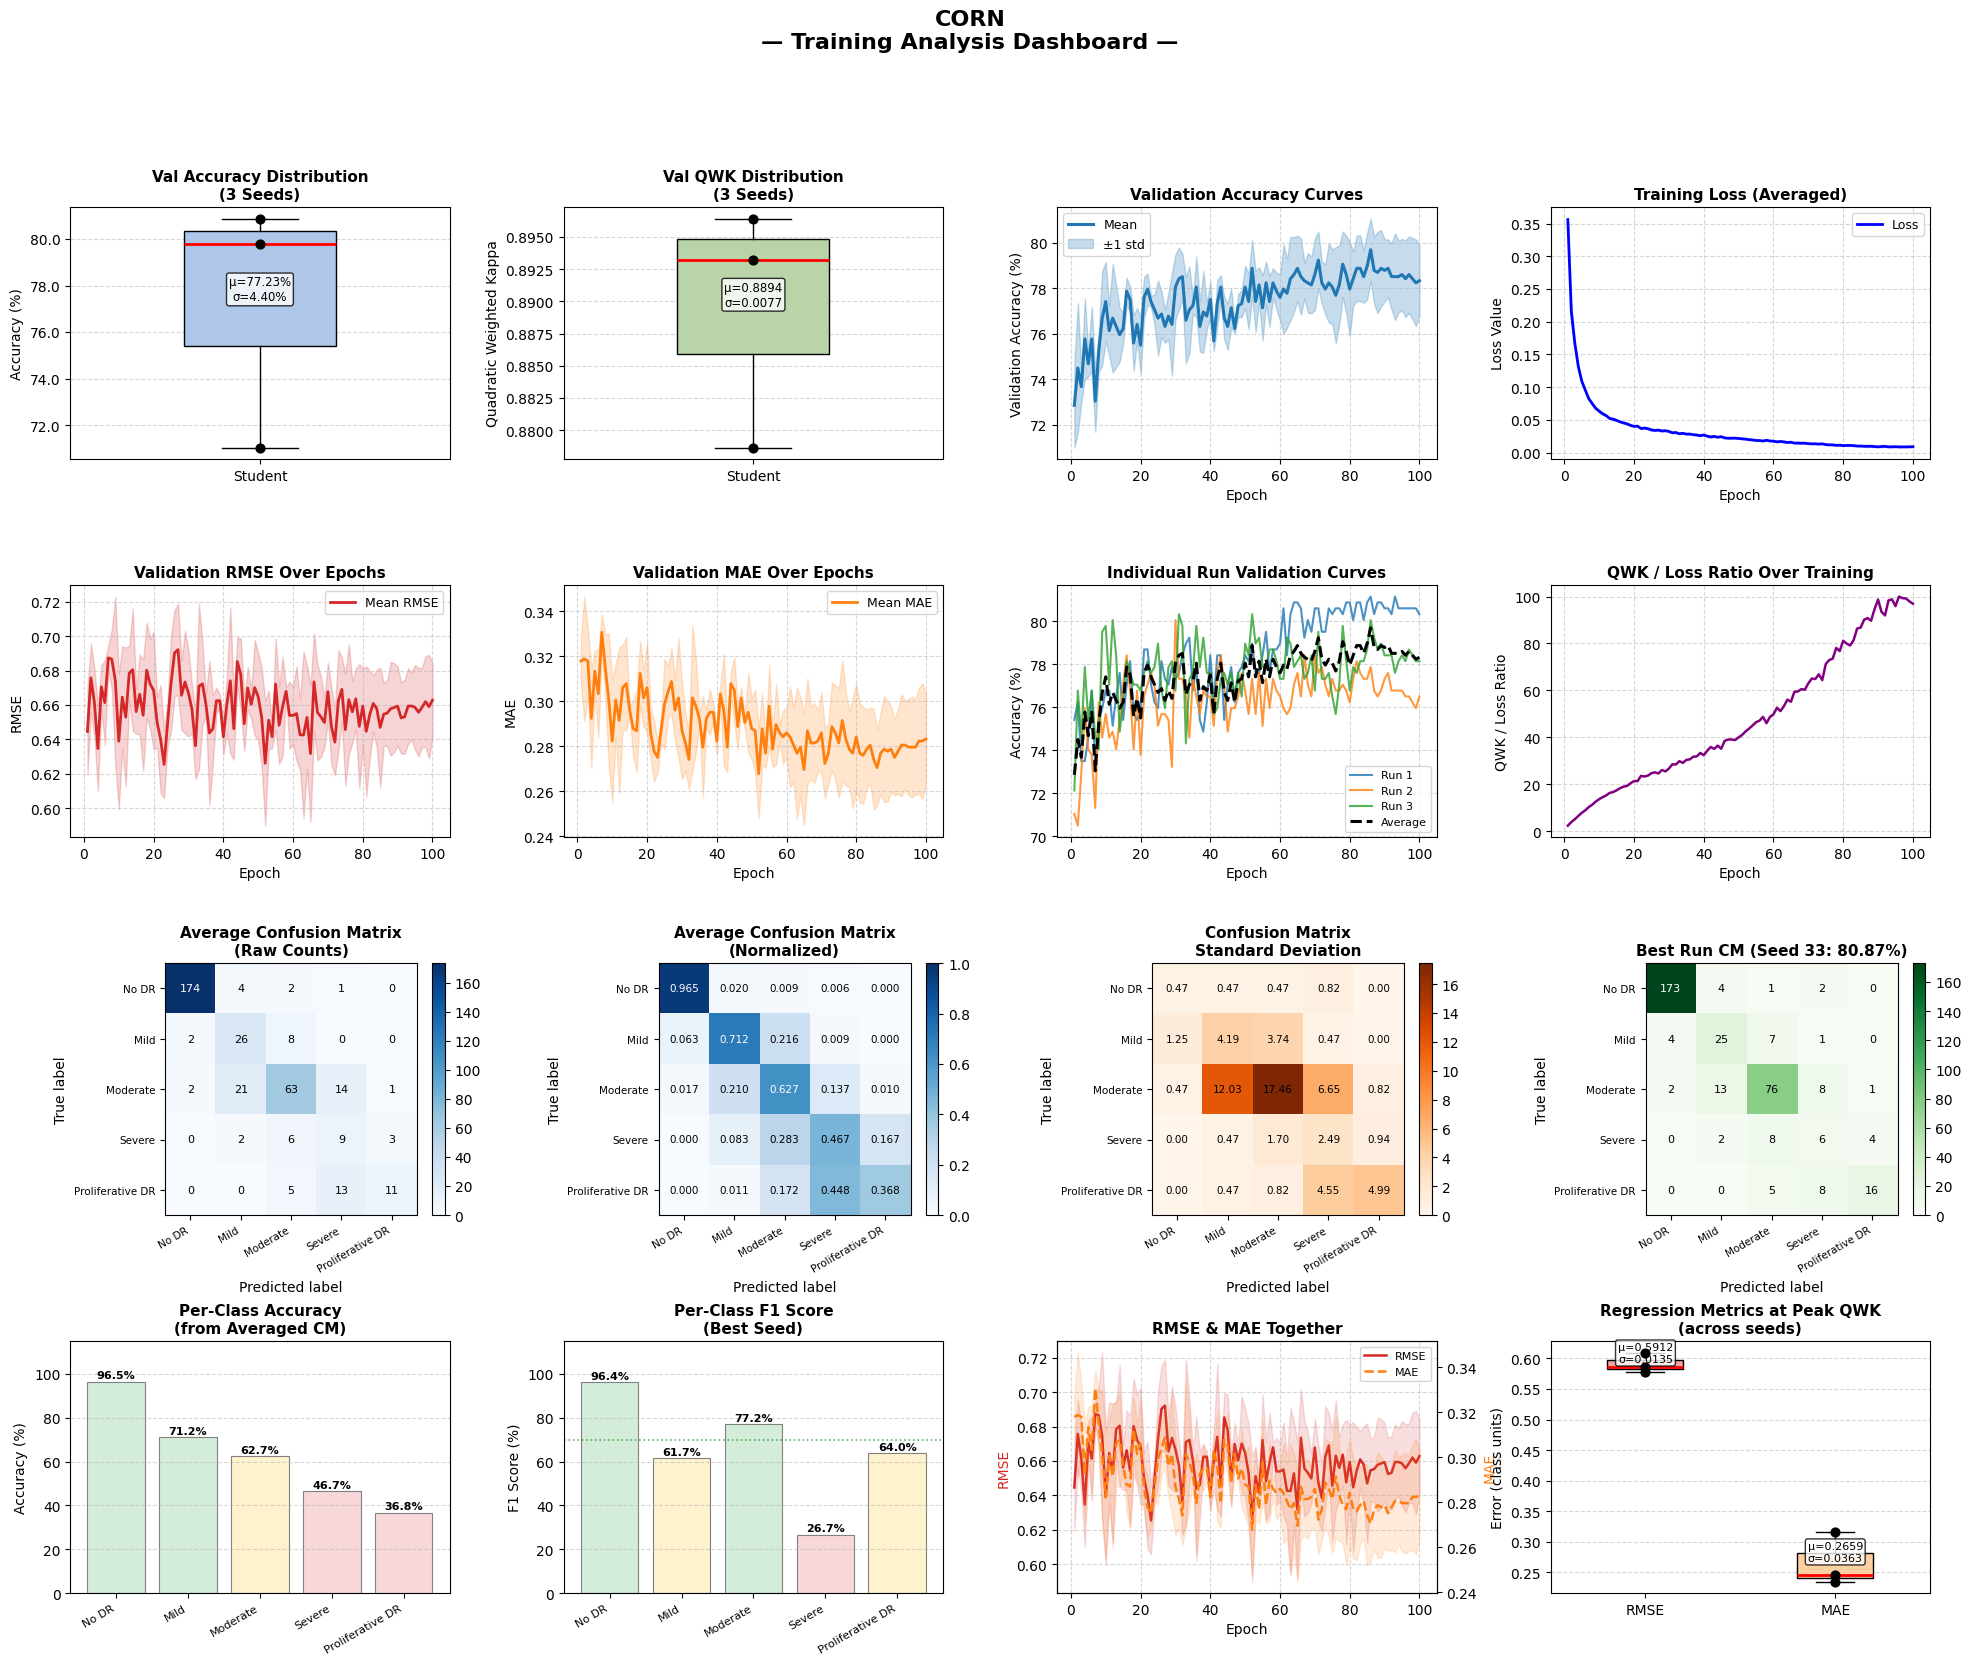

/tmp/ipykernel_57/3208451601.py:451: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig2.tight_layout(rect=[0, 0, 1, 0.97])


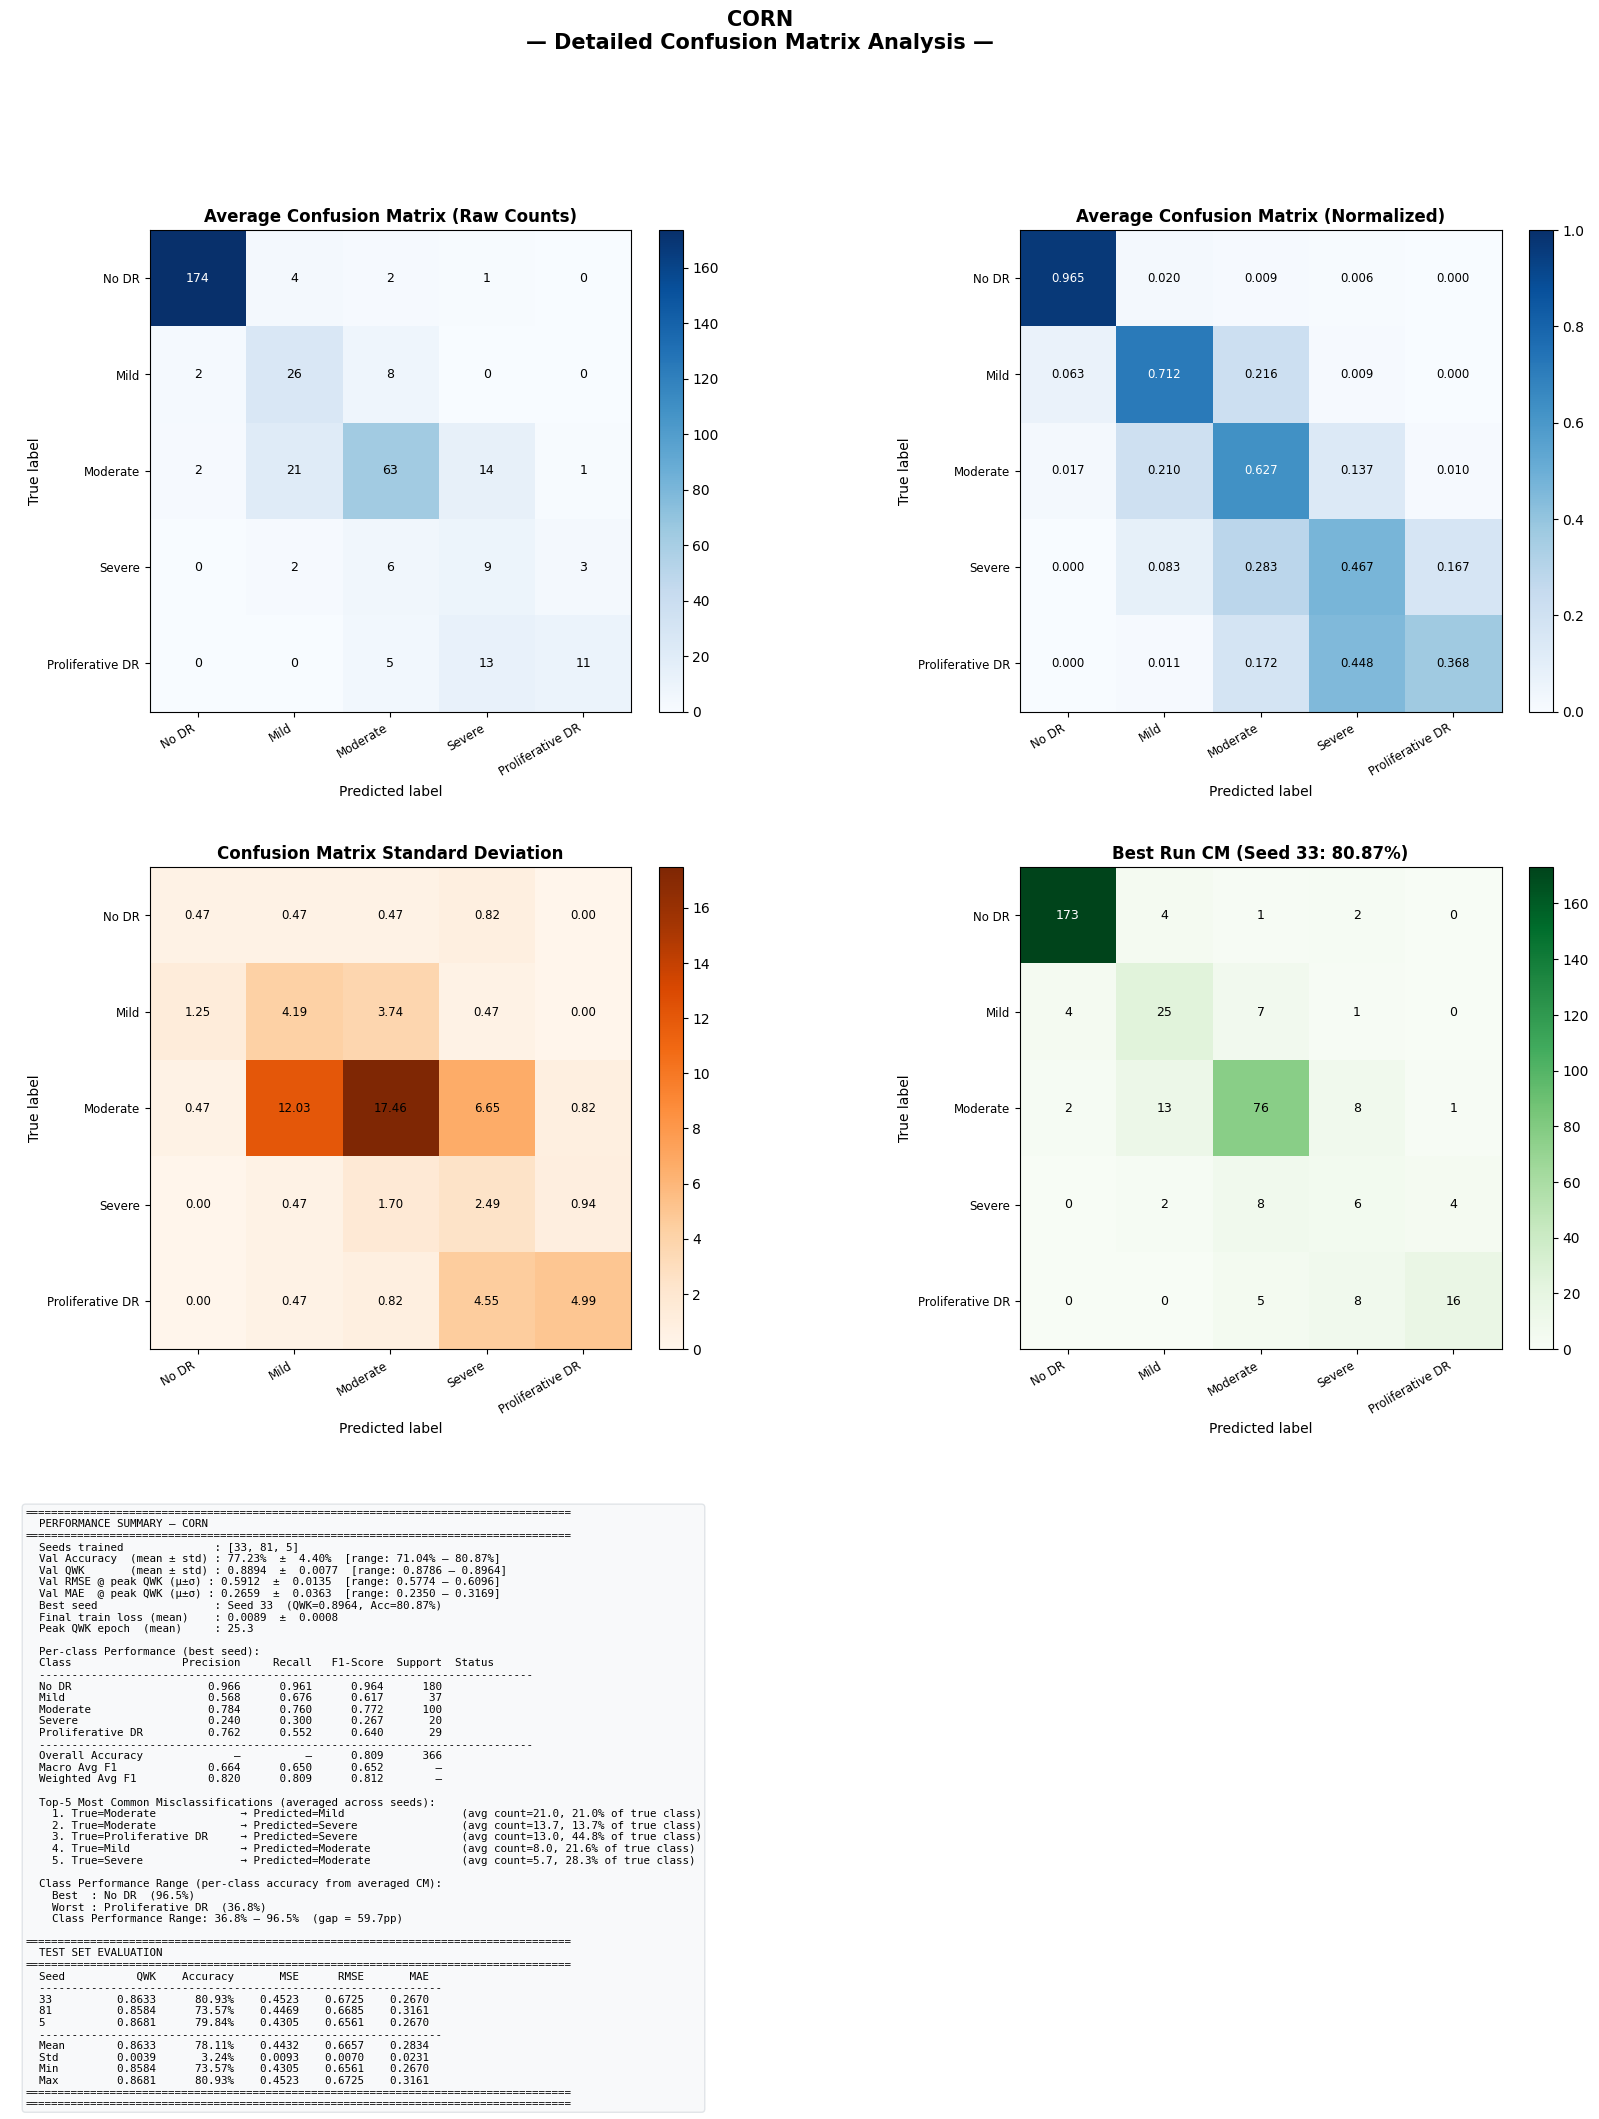

  PERFORMANCE SUMMARY — CORN
  Seeds trained              : [33, 81, 5]
  Val Accuracy  (mean ± std) : 77.23%  ±  4.40%  [range: 71.04% – 80.87%]
  Val QWK       (mean ± std) : 0.8894  ±  0.0077  [range: 0.8786 – 0.8964]
  Val RMSE @ peak QWK (μ±σ) : 0.5912  ±  0.0135  [range: 0.5774 – 0.6096]
  Val MAE  @ peak QWK (μ±σ) : 0.2659  ±  0.0363  [range: 0.2350 – 0.3169]
  Best seed                  : Seed 33  (QWK=0.8964, Acc=80.87%)
  Final train loss (mean)    : 0.0089  ±  0.0008
  Peak QWK epoch  (mean)     : 25.3

  Per-class Performance (best seed):
  Class                 Precision     Recall   F1-Score  Support  Status
  ----------------------------------------------------------------------------
  No DR                     0.966      0.961      0.964      180
  Mild                      0.568      0.676      0.617       37
  Moderate                  0.784      0.760      0.772      100
  Severe                    0.240      0.300      0.267       20
  Proliferative DR          0.7

In [16]:
analyse_results(results_s_corn, "CORN", test_results_list=test_results_corn)